# LSTM Benchmark: spdin/time-series-prediction-lstm-pytorch

This notebook evaluates the next external LSTM benchmark implementation based on the local repository:

- `time-series-prediction-lstm-pytorch-master/time-series-prediction-lstm-pytorch-master`

The goal is to test whether its PyTorch LSTM code can be reused for the unified M5 benchmark.

## Repo Inspection Summary

Found locally:
- `time-series-prediction-lstm-pytorch-master/time-series-prediction-lstm-pytorch-master`

Useful files identified:
- `Time_Series_Prediction_with_LSTM_Using_PyTorch.ipynb`
- `README.md`

Reusable code identified:
- `sliding_windows(...)`
- PyTorch `LSTM(nn.Module)` definition
- training loop with `MSELoss` and `Adam`

Critical note:
- this repo is a compact tutorial/demo on shampoo and airline datasets
- it is not a full forecasting package
- still, its core PyTorch LSTM implementation is clean enough to reuse with minimal adaptation

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == 'gnn_model_comparison':
    ROOT = ROOT.parent.parent
elif ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data_loaders.load_m5 import load_m5_single_series
from src.experiments.common_protocol import OFFICIAL_BENCHMARK_PROTOCOL, split_series_protocol
from src.metrics.behavioral_metrics import behavioral_metrics
from src.models.spdin_repo_lstm import SpdinRepoLSTMForecastModel

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
np.random.seed(OFFICIAL_BENCHMARK_PROTOCOL.seed)

In [2]:
CONFIG = {
    'M5_BASE_PATH': ROOT / 'data' / 'raw' / 'm5',
    'REPO_PATH': ROOT / 'time-series-prediction-lstm-pytorch-master' / 'time-series-prediction-lstm-pytorch-master',
    'BENCHMARK_PRODUCTS': [
        {'series_id': 'FOODS_3_228_CA_1_validation', 'label': 'high_demand_stable'},
        {'series_id': 'FOODS_2_044_CA_3_validation', 'label': 'intermittent'},
        {'series_id': 'HOBBIES_1_133_CA_4_validation', 'label': 'low_volume'},
    ],
    'MAX_DAYS': OFFICIAL_BENCHMARK_PROTOCOL.max_days,
    'CONTEXT_LENGTH': OFFICIAL_BENCHMARK_PROTOCOL.context_length,
    'VAL_DAYS': OFFICIAL_BENCHMARK_PROTOCOL.val_days,
    'TEST_DAYS': OFFICIAL_BENCHMARK_PROTOCOL.test_days,
    'HIDDEN_SIZE': 2,
    'NUM_LAYERS': 1,
    'EPOCHS': 2000,
    'LR': 0.01,
    'SEED': OFFICIAL_BENCHMARK_PROTOCOL.seed,
    'FLAT_VARIANCE_RATIO_THRESHOLD': 0.10,
    'OUTPUT_DIR': ROOT / 'reports' / 'gnn_benchmarks' / 'spdin_repo_lstm_impl4',
}
CONFIG

{'M5_BASE_PATH': WindowsPath('c:/Users/braya/Documents/Research/aurex-demand-forecasting-main/data/raw/m5'),
 'REPO_PATH': WindowsPath('c:/Users/braya/Documents/Research/aurex-demand-forecasting-main/time-series-prediction-lstm-pytorch-master/time-series-prediction-lstm-pytorch-master'),
 'BENCHMARK_PRODUCTS': [{'series_id': 'FOODS_3_228_CA_1_validation',
   'label': 'high_demand_stable'},
  {'series_id': 'FOODS_2_044_CA_3_validation', 'label': 'intermittent'},
  {'series_id': 'HOBBIES_1_133_CA_4_validation', 'label': 'low_volume'}],
 'MAX_DAYS': 365,
 'CONTEXT_LENGTH': 28,
 'VAL_DAYS': 28,
 'TEST_DAYS': 28,
 'HIDDEN_SIZE': 2,
 'NUM_LAYERS': 1,
 'EPOCHS': 2000,
 'LR': 0.01,
 'SEED': 42,
 'FLAT_VARIANCE_RATIO_THRESHOLD': 0.1,
 'OUTPUT_DIR': WindowsPath('c:/Users/braya/Documents/Research/aurex-demand-forecasting-main/reports/gnn_benchmarks/spdin_repo_lstm_impl4')}

In [3]:
def flat_nonflat_label(variance_ratio: float, threshold: float = 0.10) -> str:
    return 'flat' if float(variance_ratio) < float(threshold) else 'non-flat'


def evaluate_one(series_id: str, benchmark_label: str) -> dict:
    df = load_m5_single_series(
        base_path=str(CONFIG['M5_BASE_PATH']),
        random_pick=False,
        series_id=series_id,
    )
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True)
    df = df.iloc[-CONFIG['MAX_DAYS']:].copy().reset_index(drop=True)

    y = df['sales'].to_numpy(dtype=float)
    y_train, y_val, y_test = split_series_protocol(
        y,
        val_days=CONFIG['VAL_DAYS'],
        test_days=CONFIG['TEST_DAYS'],
    )
    y_fit = np.concatenate([y_train, y_val])

    model = SpdinRepoLSTMForecastModel(
        context_length=CONFIG['CONTEXT_LENGTH'],
        hidden_size=CONFIG['HIDDEN_SIZE'],
        num_layers=CONFIG['NUM_LAYERS'],
        epochs=CONFIG['EPOCHS'],
        lr=CONFIG['LR'],
        seed=CONFIG['SEED'],
    )
    model.fit(y_fit, scaling_reference=y_train)
    y_pred, conf_low, conf_up = model.forecast(len(y_test), y_fit)

    val_end = len(y_train) + len(y_val)
    test_df = df.iloc[val_end:].copy().reset_index(drop=True)
    pred_df = test_df[['date', 'sales']].copy()
    pred_df['y_pred'] = y_pred
    pred_df['conf_low'] = conf_low
    pred_df['conf_up'] = conf_up
    pred_df['series_id'] = series_id
    pred_df['benchmark_label'] = benchmark_label

    beh = behavioral_metrics(y_test, y_pred)
    variance_ratio = float(beh['variance_ratio'])
    metrics_row = {
        'series_id': series_id,
        'benchmark_label': benchmark_label,
        'model': 'SpdinRepoLSTM',
        'train_days': int(len(y_train)),
        'val_days': int(len(y_val)),
        'fit_days': int(len(y_fit)),
        'test_days': int(len(y_test)),
        'context_length': CONFIG['CONTEXT_LENGTH'],
        'hidden_size': CONFIG['HIDDEN_SIZE'],
        'num_layers': CONFIG['NUM_LAYERS'],
        'epochs': CONFIG['EPOCHS'],
        'lr': CONFIG['LR'],
        'final_loss': float(model.training_history_.get('final_loss', np.nan)),
        'mae': float(np.mean(np.abs(y_test - y_pred))),
        'rmse': float(np.sqrt(np.mean((y_test - y_pred) ** 2))),
        'pred_std': float(np.std(y_pred)),
        'real_std': float(np.std(y_test)),
        'variance_ratio': variance_ratio,
        'trend_correlation': float(beh['trend_correlation']),
        'direction_accuracy': float(beh['direction_accuracy']),
        'shape_similarity': float(beh['shape_similarity']),
        'peak_detection_rate': float(beh['peak_detection_rate']),
        'n_peaks_real': int(beh['n_peaks_real']),
        'n_peaks_detected': int(beh['n_peaks_detected']),
        'flat_nonflat': flat_nonflat_label(variance_ratio, CONFIG['FLAT_VARIANCE_RATIO_THRESHOLD']),
    }
    return {
        'series_id': series_id,
        'benchmark_label': benchmark_label,
        'pred_df': pred_df,
        'metrics_row': metrics_row,
    }

In [4]:
runs = [evaluate_one(cfg['series_id'], cfg['label']) for cfg in CONFIG['BENCHMARK_PRODUCTS']]

training_summary_df = pd.DataFrame([
    {
        'series_id': run['series_id'],
        'benchmark_label': run['benchmark_label'],
        'train_days': run['metrics_row']['train_days'],
        'val_days': run['metrics_row']['val_days'],
        'fit_days': run['metrics_row']['fit_days'],
        'test_days': run['metrics_row']['test_days'],
        'context_length': run['metrics_row']['context_length'],
        'hidden_size': run['metrics_row']['hidden_size'],
        'num_layers': run['metrics_row']['num_layers'],
        'epochs': run['metrics_row']['epochs'],
        'lr': run['metrics_row']['lr'],
        'final_loss': run['metrics_row']['final_loss'],
    }
    for run in runs
])
metrics_df = pd.DataFrame([run['metrics_row'] for run in runs])
predictions_df = pd.concat([run['pred_df'] for run in runs], ignore_index=True)

display(training_summary_df)
display(metrics_df)

,series_id,benchmark_label,train_days,val_days,fit_days,test_days,context_length,hidden_size,num_layers,epochs,lr,final_loss
0,FOODS_3_228_CA_1_validation,high_demand_stable,309,28,337,28,28,2,1,2000,0.0100,0.0229
1,FOODS_2_044_CA_3_validation,intermittent,309,28,337,28,28,2,1,2000,0.0100,0.0316
2,HOBBIES_1_133_CA_4_validation,low_volume,309,28,337,28,28,2,1,2000,0.0100,0.0127


,series_id,benchmark_label,model,train_days,val_days,fit_days,test_days,context_length,hidden_size,num_layers,epochs,lr,final_loss,mae,rmse,pred_std,real_std,variance_ratio,trend_correlation,direction_accuracy,shape_similarity,peak_detection_rate,n_peaks_real,n_peaks_detected,flat_nonflat
0,FOODS_3_228_CA_1_validation,high_demand_stable,SpdinRepoLSTM,309,28,337,28,28,2,1,2000,0.0100,0.0229,2.2461,2.7672,0.5131,2.7818,0.1844,0.6265,0.5556,0.6781,0.0000,8,0,non-flat
1,FOODS_2_044_CA_3_validation,intermittent,SpdinRepoLSTM,309,28,337,28,28,2,1,2000,0.0100,0.0316,1.1219,1.5024,0.0677,1.4569,0.0465,0.4090,0.3333,0.5197,0.0000,5,0,flat
2,HOBBIES_1_133_CA_4_validation,low_volume,SpdinRepoLSTM,309,28,337,28,28,2,1,2000,0.0100,0.0127,0.0352,0.0353,0.0027,0.0000,0.0000,NaN,0.0000,0.1772,1.0000,0,0,flat


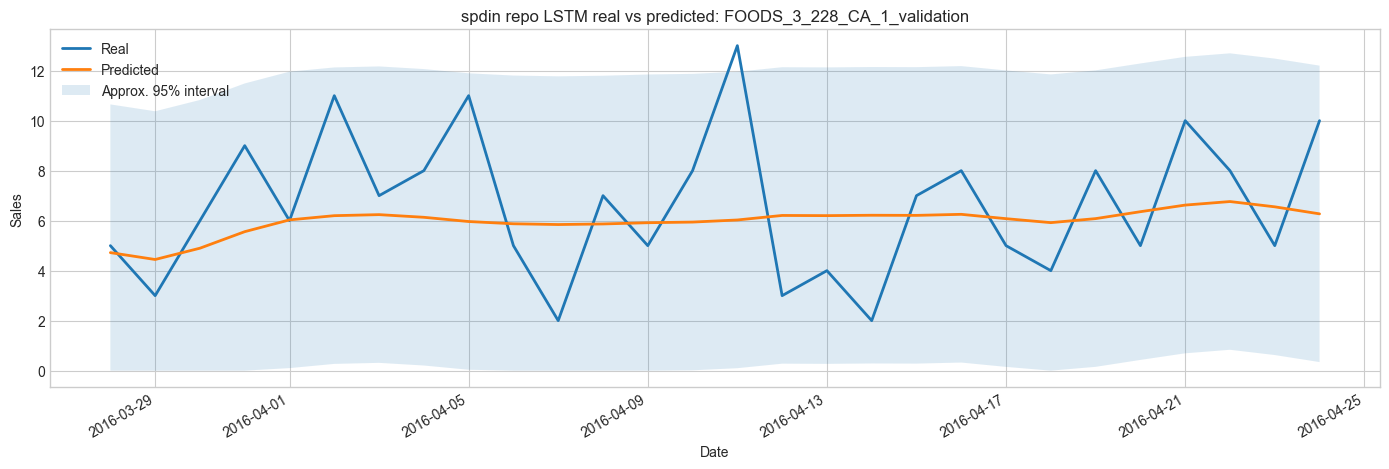

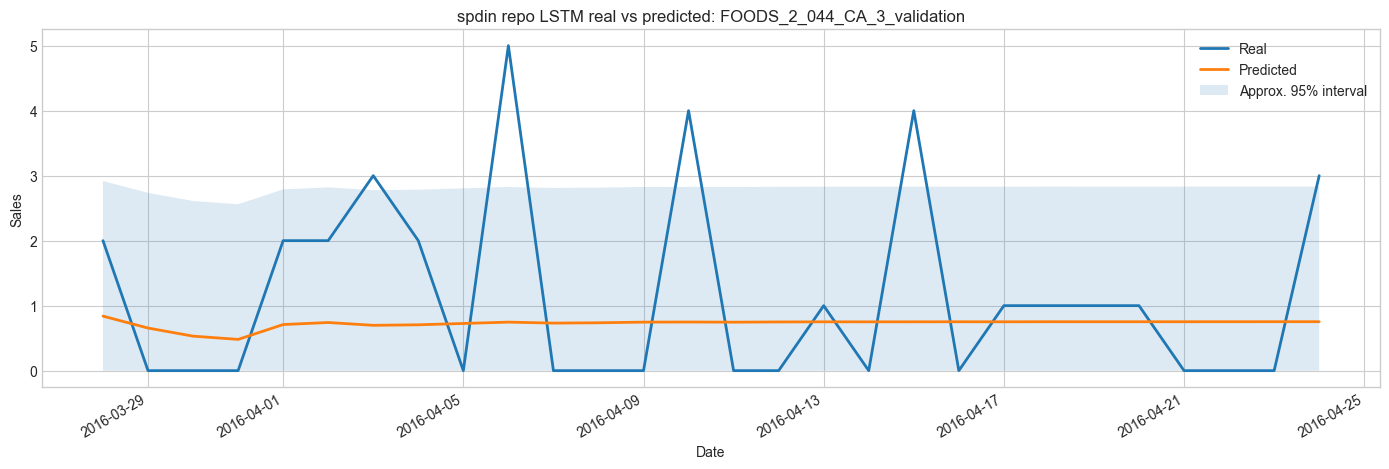

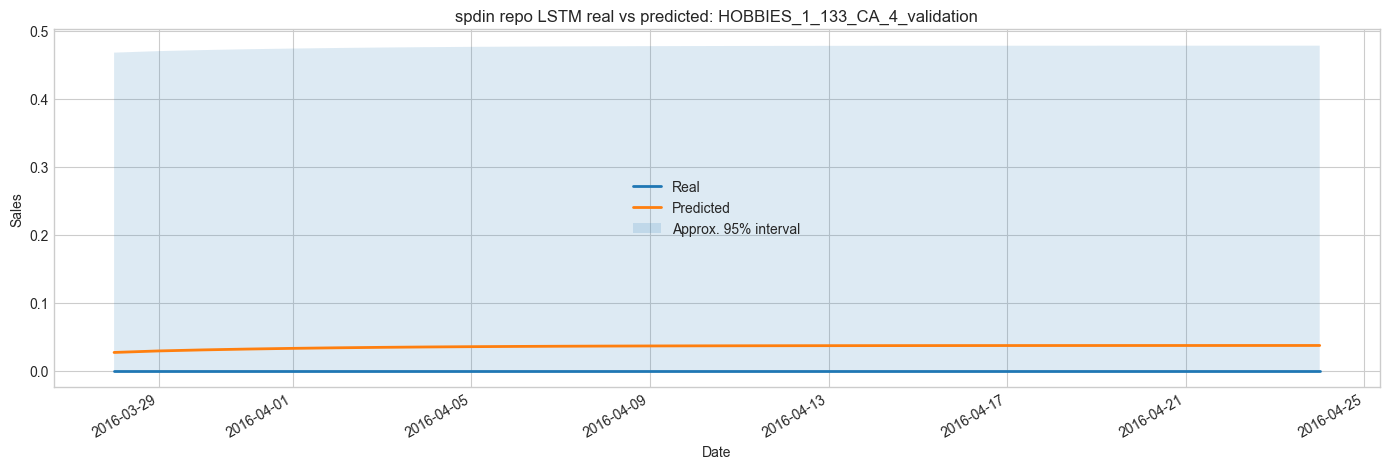

In [5]:
for run in runs:
    plot_df = run['pred_df']
    fig, ax = plt.subplots(figsize=(14, 4.8))
    ax.plot(plot_df['date'], plot_df['sales'], label='Real', linewidth=2)
    ax.plot(plot_df['date'], plot_df['y_pred'], label='Predicted', linewidth=2)
    ax.fill_between(plot_df['date'], plot_df['conf_low'], plot_df['conf_up'], alpha=0.15, label='Approx. 95% interval')
    ax.set_title(f"spdin repo LSTM real vs predicted: {run['series_id']}")
    ax.set_xlabel('Date')
    ax.set_ylabel('Sales')
    ax.legend()
    fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()

In [6]:
conclusion_df = metrics_df[
    [
        'series_id',
        'benchmark_label',
        'final_loss',
        'mae',
        'rmse',
        'pred_std',
        'real_std',
        'variance_ratio',
        'trend_correlation',
        'direction_accuracy',
        'shape_similarity',
        'peak_detection_rate',
        'flat_nonflat',
    ]
].copy()
display(conclusion_df)

,series_id,benchmark_label,final_loss,mae,rmse,pred_std,real_std,variance_ratio,trend_correlation,direction_accuracy,shape_similarity,peak_detection_rate,flat_nonflat
0,FOODS_3_228_CA_1_validation,high_demand_stable,0.0229,2.2461,2.7672,0.5131,2.7818,0.1844,0.6265,0.5556,0.6781,0.0000,non-flat
1,FOODS_2_044_CA_3_validation,intermittent,0.0316,1.1219,1.5024,0.0677,1.4569,0.0465,0.4090,0.3333,0.5197,0.0000,flat
2,HOBBIES_1_133_CA_4_validation,low_volume,0.0127,0.0352,0.0353,0.0027,0.0000,0.0000,NaN,0.0000,0.1772,1.0000,flat


## Final Verdict

This repo is reusable enough for the benchmark because:
- it contains a concrete PyTorch LSTM forecasting implementation
- the core model and training loop are small and portable

But it is still a tutorial/demo repo, so:
- it is not a full forecasting framework
- the benchmark adaptation still had to add chronological split, scaling discipline, and recursive future rollout

In [7]:
out_dir = CONFIG['OUTPUT_DIR']
out_dir.mkdir(parents=True, exist_ok=True)

training_summary_path = out_dir / 'training_summary_from_notebook.csv'
metrics_path = out_dir / 'metrics_from_notebook.csv'
predictions_path = out_dir / 'predictions_from_notebook.csv'
conclusion_path = out_dir / 'flat_nonflat_conclusion_from_notebook.csv'

training_summary_df.to_csv(training_summary_path, index=False)
metrics_df.to_csv(metrics_path, index=False)
predictions_df.to_csv(predictions_path, index=False)
conclusion_df.to_csv(conclusion_path, index=False)

print(f'Saved: {training_summary_path}')
print(f'Saved: {metrics_path}')
print(f'Saved: {predictions_path}')
print(f'Saved: {conclusion_path}')

Saved: c:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\gnn_benchmarks\spdin_repo_lstm_impl4\training_summary_from_notebook.csv
Saved: c:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\gnn_benchmarks\spdin_repo_lstm_impl4\metrics_from_notebook.csv
Saved: c:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\gnn_benchmarks\spdin_repo_lstm_impl4\predictions_from_notebook.csv
Saved: c:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\gnn_benchmarks\spdin_repo_lstm_impl4\flat_nonflat_conclusion_from_notebook.csv
